# Исследование поведения пользователей и юнит-экономики интернет-магазина

Смотрим на реальные данные e-commerce платформы: откуда приходят клиенты, как они двигаются по воронке в приложении, что покупают и через сколько дней возвращаются за повторным заказом

Стек: Python, Pandas, PandasSQL, Seaborn

Что разбираем в проекте:
* Категории товаров: где самый высокий чек и какие товары чаще всего возвращают
* Топ-покупатели: кто приносит больше всего денег в разных странах (оконная функция DENSE_RANK)
* Возвращаемость: сколько дней в среднем проходит между первой и второй покупкой (оконная функция LEAD)
* Когорты: как меняется выручка по месяцам регистрации пользователей
* Воронка приложения: на каком именно шаге отваливается больше всего людей
* Маркетинговые каналы: сравниваем конверсию в покупку, процент повторных заказов и итоговый LTV

### 1. Загрузка таблиц
Подключаем библиотеки и читаем три таблицы:
* `orders` — сами заказы, их статус, суммы и скидки
* `users` — пользователи, даты регистрации, страны и рекламные каналы
* `user_actions` — действия внутри приложения (клики, просмотры, чекаут)

In [ ]:
import pandas as pd 
from pandasql import sqldf
import seaborn as sns 
import matplotlib.pyplot as plt 

orders = pd.read_csv('orders.csv')
user_actions =pd.read_csv('user_actions.csv')
users = pd.read_csv('users.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'orders.csv'

### 2. Категории: выручка, средний чек и отмены
Считаем чистую выручку с учетом скидок только по успешным заказам, средний чек и процент отмененных или возвращенных покупок

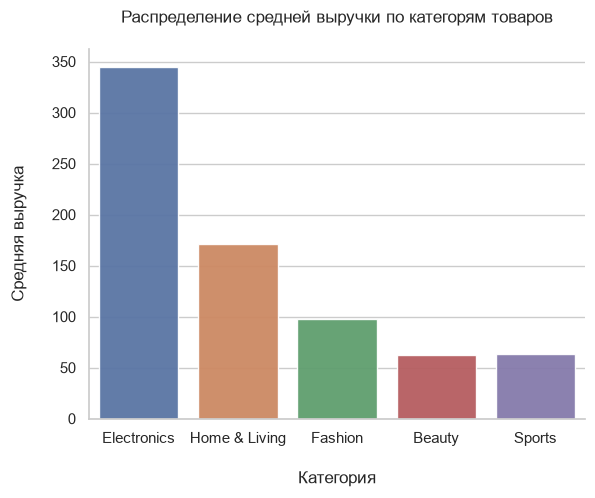

In [2]:
query_statisctics = """
SELECT 
    category,
    COUNT(*) AS cnt_all,
    COUNT(CASE WHEN status = 'completed' then 1 end) as cnt_success,
    ROUND(SUM((CASE WHEN status = 'completed' then order_amount_usd - discount_usd end)),0) as total_revenue,
    ROUND(AVG(CASE WHEN status = 'completed' then order_amount_usd - discount_usd end),0) AS mean_check,
    ROUND((AVG(CASE WHEN status = 'cancelled' or status = 'refunded'  then 1 else 0 end)*100.0),1) as percent_cancelled_n_refund
FROM orders
GROUP BY category
ORDER BY total_revenue DESC
"""

sql_df1 = sqldf(query_statisctics, globals())
sql_df1

sns.set(style = 'whitegrid')
ax2 = sns.barplot(data  =sql_df1, x = 'category' ,  y = 'mean_check', hue = ['r','g','b','y','p'], legend = False, alpha = 0.95)
ax2.set_title(f'Распределение средней выручки по категорям товаров\n')
ax2.set_xlabel(f'\nКатегория')
ax2.set_ylabel(f'Средняя выручка\n')
sns.despine()


> Вывод по категориям: Электроника ожидаемо лидирует по среднему чеку (около $345), на втором месте товары для дома (~$170), а одежда, косметика и спорт держатся в районе $60–100

### 3. Топ-3 покупателя в каждой стране
Через DENSE_RANK() ранжируем клиентов по суммарным тратам внутри каждой страны и отбираем тройку лидеров

C:\Users\user\AppData\Local\Temp\ipykernel_17660\864009181.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(['Canada','Germany','France','UK','US'])


Text(0, 0.5, 'Общее ревеню\n')

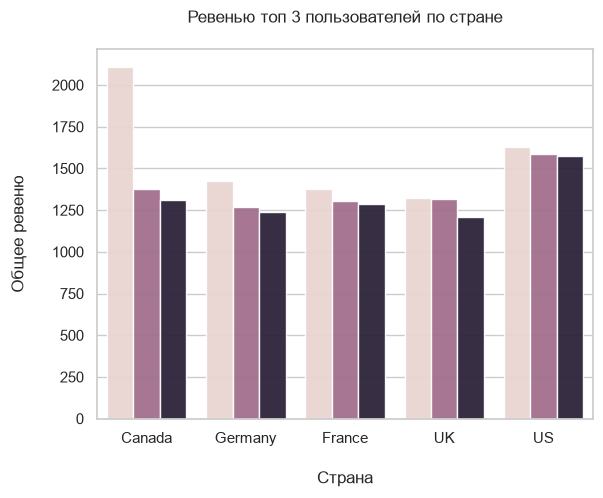

In [41]:
top_country_us = """
WITH top_country_users as (
    SELECT
        u.user_id,
        u.country,
        SUM(order_amount_usd - discount_usd) as total_user_revenue,
        DENSE_RANK() OVER (PARTITION BY country ORDER BY SUM(order_amount_usd - discount_usd) DESC) AS rnk_country
    FROM users u
    JOIN orders o ON u.user_id = o.user_id AND o.status = 'completed'
    GROUP BY u.user_id, u.country
)
SELECT 
    country,
    user_id,
    ROUND(total_user_revenue,1) as user_revenue,
    rnk_country
FROM top_country_users
WHERE rnk_country <=3
ORDER BY country ASC , rnk_country ASC
"""
sql_df2 = sqldf(top_country_us, globals())
sql_df2

sns.set(style = 'whitegrid')
ax = sns.barplot(data = sql_df2, x = 'country', hue = 'rnk_country', y  = 'user_revenue',legend = False, alpha = 0.95)
ax.set_xticklabels(['Canada','Germany','France','UK','US'])
ax.set_title(f'Ревенью топ 3 пользователей по стране\n')
ax.set_xlabel(f'\nСтрана')
ax.set_ylabel(f'Общее ревеню\n')

> Вывод по странам: Самые крупные чеки у топов в США (каждый потратил больше $1600), в остальных странах топ-покупатели идут примерно на одном уровне ($1250–1400)

### 4. Через сколько дней клиенты делают повторный заказ
Берем пользователей минимум с двумя покупками и через LEAD() считаем разницу в днях между заказами

In [4]:
us_interval = """
WITH more2_us AS(
    SELECT 
        user_id
    FROM orders 
    GROUP BY user_id
    HAVING COUNT(CASE WHEN status = 'completed' then 1 end) >= 2
),
us_info AS(
    SELECT 
        user_id,
        order_date,
        julianday(LEAD(order_date) OVER (PARTITION BY user_id ORDER BY order_date)) - julianday(order_date) as diff
    FROM orders 
    WHERE user_id in (SELECT * FROM more2_us) AND status = 'completed'
)
SELECT 
    ROUND(AVG(diff),0) as avg_days_before_next_purchase
FROM us_info
"""
sql_df3 = sqldf(us_interval, globals())
sql_df3

,avg_days_before_next_purchase
0,12.0


> Вывод по частоте покупок: В среднем клиенты возвращаются за вторым заказом ровно через 12 дней. Это отличный ориентир для пушей и триггерных рассылок с персональными скидками

### 5. Когортный анализ выручки
Группируем пользователей по месяцу регистрации и смотрим, как они тратят деньги по месяцам с накопительным итогом

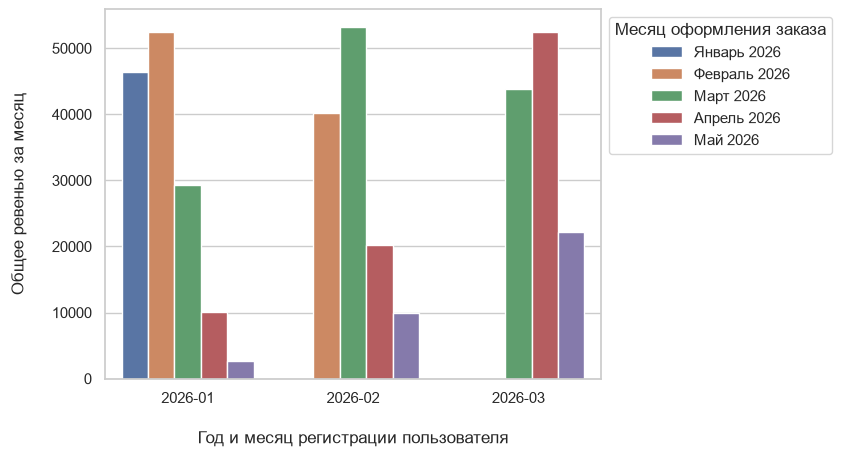

In [32]:
com_sum_df = """
SELECT 
    STRFTIME('%Y-%m', u.signup_date) as ym_reg,
    STRFTIME('%Y-%m', o.order_date) as ym_order,
    ROUND(SUM(o.order_amount_usd - o.discount_usd),0) AS month_sum,
    ROUND(SUM(SUM(o.order_amount_usd - o.discount_usd)) OVER (PARTITION BY STRFTIME('%Y-%m', u.signup_date) ORDER BY STRFTIME('%Y-%m', o.order_date) ASC),0) as com_sum_month
FROM users u 
JOIN orders o on u.user_id = o.user_id AND o.status = 'completed'
GROUP BY STRFTIME('%Y-%m', signup_date),STRFTIME('%Y-%m', o.order_date)
ORDER BY ym_reg,ym_order
"""

sql_df4 = sqldf(com_sum_df, globals())
sql_df4['ym_order'] = sql_df4['ym_order'].map({'2026-01':'Январь 2026',
                                                '2026-02':'Февраль 2026',
                                                '2026-03':'Март 2026',
                                                '2026-04':'Апрель 2026',
                                                '2026-05':'Май 2026'})

ax0 = sns.barplot(data =sql_df4, x = 'ym_reg', hue = 'ym_order', y ='month_sum')
ax0.set_xlabel('\nГод и месяц регистрации пользователя')
ax0.set_ylabel('Общее ревенью за месяц\n')

plt.legend(bbox_to_anchor = (1,1), loc = 'upper left', title = 'Месяц оформления заказа')

> Вывод по когортам: Во всех когортах видна четкая закономерность — пик трат наступает не в месяц регистрации, а на второй месяц (рост с ~$40–46k до ~$52–53k). В первый месяц клиенты присматриваются и делают небольшие пробные заказы, а на второй месяц выходят на максимальную активность. Начиная с третьего месяца идет естественный спад активности, что подчеркивает важность работы с удержанием (retention)

### 6. Воронка в мобильном приложении
Считаем пошаговую конверсию (CR) от открытия приложения до успешной оплаты:
открытие ➔ просмотр товара ➔ корзина ➔ начало чекаута ➔ оплата

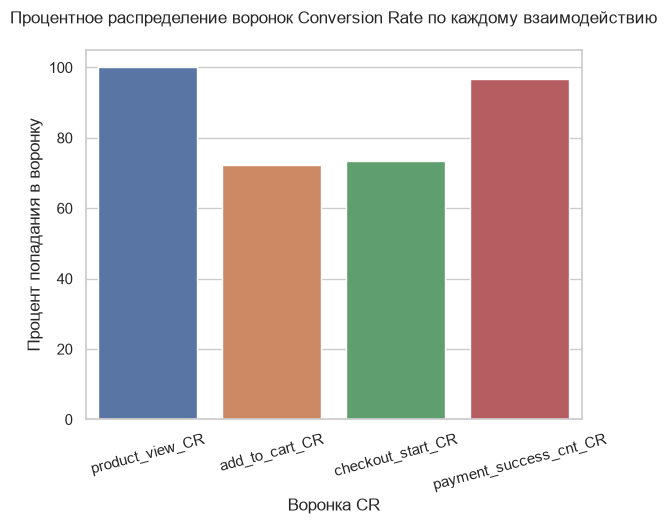

In [36]:
CR_df = """
WITH all_cnt AS (
    SELECT
        COUNT(DISTINCT CASE WHEN event_type = 'app_open' then user_id end) as app_open_cnt,
        COUNT(DISTINCT CASE WHEN event_type = 'product_view' then user_id end) as product_view_cnt,
        COUNT(DISTINCT CASE WHEN event_type = 'add_to_cart' then user_id end) as add_to_cart_cnt,
        COUNT(DISTINCT CASE WHEN event_type = 'checkout_start' then user_id end) as checkout_start_cnt,
        COUNT(DISTINCT CASE WHEN event_type = 'payment_success' then user_id end) as payment_success_cnt
    FROM user_actions
)
SELECT
    ROUND(product_view_cnt * 100.0 / app_open_cnt,1) AS product_view_CR,
    ROUND(add_to_cart_cnt * 100.0 / product_view_cnt,1) AS add_to_cart_CR,
    ROUND(checkout_start_cnt * 100.0 / add_to_cart_cnt,1) AS checkout_start_CR,
    ROUND(payment_success_cnt * 100.0 / checkout_start_cnt,1) AS payment_success_cnt_CR
FROM all_cnt

"""
sql_df5 = sqldf(CR_df, globals()).T.reset_index().rename(columns = {'index':'Воронка CR',0:'Процент попадания в воронку'})
sql_df5
ax4 = sns.barplot(data = sql_df5, x = 'Воронка CR', y = 'Процент попадания в воронку', hue = ['r','g','b','y'],legend = False)
ax4.set_title('Процентное распределение воронок Conversion Rate по каждому взаимодействию\n')
ax4.tick_params(axis = 'x',rotation = 15)


> Вывод по воронке: Главная потеря происходит на шаге из просмотра товара в корзину (конверсия 72%, то есть 28% уходят без добавления в корзину). Зато те, кто дошел до чекаута, в 88% случаев успешно оплачивают заказ

### 7. Эффективность рекламных каналов и LTV
Смотрим на качество трафика по источникам: процент первой покупки, долю повторных заказов и средний LTV на пользователя

Text(0, 0.5, 'LTV в долларах')

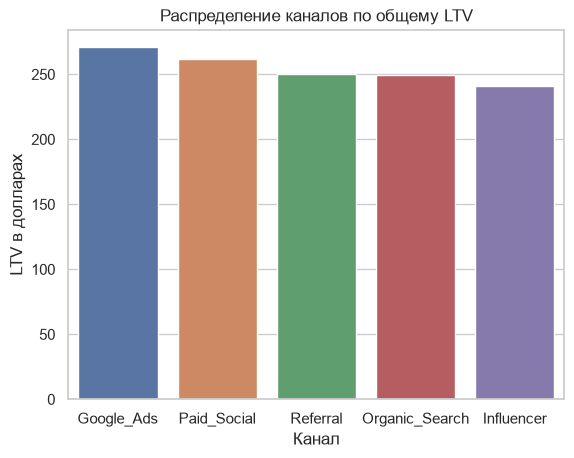

In [40]:
com_sum_df = """
WITH cnt as(
    SELECT
        u.user_id,
        u.channel,
        COUNT(CASE WHEN o.status = 'completed' then 1 end) AS successful_cnt,
        COALESCE(SUM(CASE WHEN o.status = 'completed' then o.order_amount_usd - o.discount_usd END), 0.0) AS us_revenue
    FROM users u
    LEFT JOIN orders o ON u.user_id = o.user_id
    GROUP BY u.user_id, u.channel
)
SELECT 
    channel,
    COUNT(DISTINCT user_id) as user_cnt,
    ROUND(COUNT(CASE WHEN successful_cnt >=1 THEN user_id end) * 100.0 / COUNT(DISTINCT user_id),1) AS cr1_percent,
    ROUND(COUNT(CASE WHEN successful_cnt >=2 THEN user_id end) * 100.0 / COUNT(DISTINCT user_id),1) as repeat_rate_percent,
    ROUND(AVG(us_revenue),1) as avg_ltv_usd
FROM cnt
GROUP BY channel
ORDER BY avg_ltv_usd DESC
"""

sql_df6 = sqldf(com_sum_df, globals())
sql_df6

ax7 = sns.barplot(data = sql_df6, x = 'channel', y = 'avg_ltv_usd', hue = ['r','g','b','y','p'], legend = False)
ax7.set_title('Распределение каналов по общему LTV')
ax7.set_xlabel('Канал')
ax7.set_ylabel('LTV в долларах')

## Главные выводы по проекту
* По поведению когорт: основной доход клиент приносит на второй месяц после прихода на платформу (пик выручки $52k+), поэтому онбординг и удержание в первые 30-60 дней критически важны для окупаемости трафика
* По воронке: нужно перерабатывать экран карточки товара, так как именно там теряется почти треть пользователей (28%)
* По возвратам: цикл повторной покупки составляет 12 дней, поэтому рассылки и спецпредложения логично настраивать именно на этот интервал
* По категориям: электроника дает самый большой чек, но основной объем заказов идет из других категорий, есть смысл тестировать бандлы и сопутствующие товары к технике
* По маркетингу: каналы с высоким repeat rate и LTV окупаются лучше всего на дистанции, поэтому бюджет стоит перераспределять в их сторону